In [15]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

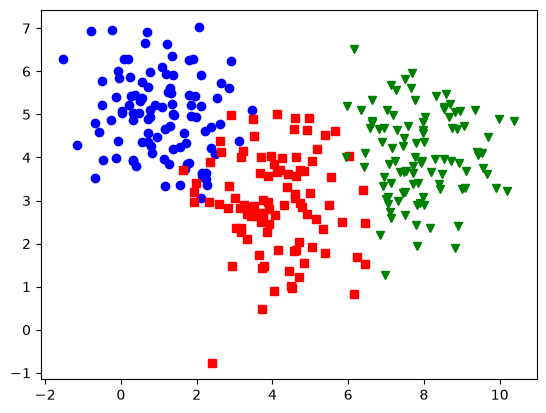

In [16]:
# Experiment 1: train a Neural Network for multi-ouput categorical classification
N = 100

a = [1, 5]
b = [4, 3]
c = [8, 4]
blur = 1

A = [a[0] + np.random.randn(N) * blur, a[1] + np.random.randn(N) * blur]
B = [b[0] + np.random.randn(N) * blur, b[1] + np.random.randn(N) * blur]
C = [c[0] + np.random.randn(N) * blur, c[1] + np.random.randn(N) * blur]
data_np = np.hstack([A, B, C]).T
data = torch.tensor(data_np).float()

labels_np = np.hstack((np.zeros((N)), np.ones((N)), np.ones((N)) * 2))
labels = torch.tensor(labels_np, dtype=torch.long)

plt.plot(data_np[np.where(labels_np == 0)[0],0], data_np[np.where(labels_np == 0)[0],1], 'bo')
plt.plot(data_np[np.where(labels_np == 1)[0],0], data_np[np.where(labels_np == 1)[0],1], 'rs')
plt.plot(data_np[np.where(labels_np == 2)[0],0], data_np[np.where(labels_np == 2)[0],1], 'gv')
plt.show()

In [17]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 3)
)
loss_func = nn.CrossEntropyLoss()
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

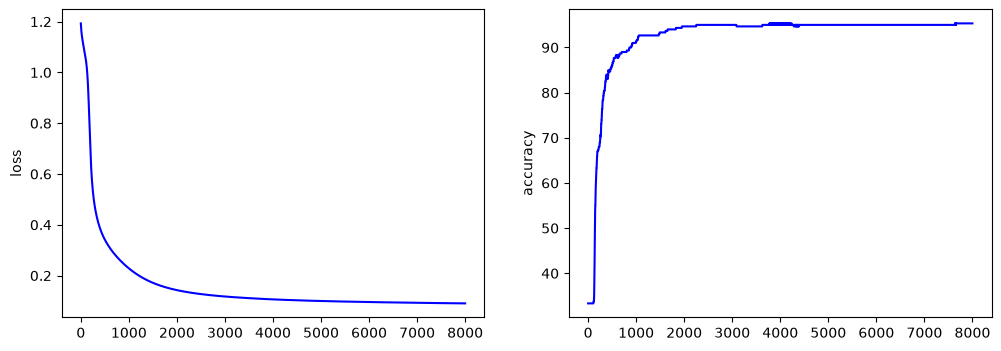

In [18]:
training_epochs = 8000
losses = np.zeros(training_epochs)
accuracies = np.zeros(training_epochs)

for epoch in range(training_epochs):
    # forward pass
    y_hat = model(data)

    # compute loss
    loss = loss_func(y_hat, labels)
    losses[epoch] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    matches = torch.argmax(y_hat, axis=1) == labels
    matches_num = matches.float()
    accuracy = 100 * torch.mean(matches_num)
    accuracies[epoch] = accuracy

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(losses, "b-")
ax[0].set_ylabel('loss')
ax[1].plot(accuracies, "b-")
ax[1].set_ylabel('accuracy')
plt.show()

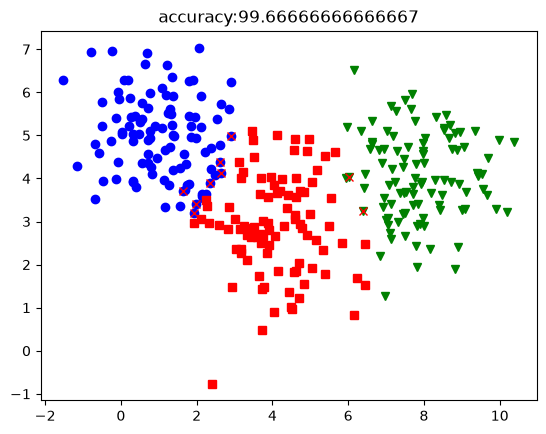

In [19]:
predictions = model(data)
predictions_softmax = torch.softmax(predictions, dim=1)
predictions_labels = torch.argmax(predictions_softmax, axis=1)
misclassifications = np.where(predictions_labels != labels)
accuracy = 100 - 100 * len(misclassifications) / len(predictions_labels)

plt.plot(data_np[np.where(predictions_labels == 0)[0],0], data_np[np.where(predictions_labels == 0)[0],1], 'bo')
plt.plot(data_np[np.where(predictions_labels == 1)[0],0], data_np[np.where(predictions_labels == 1)[0],1], 'rs')
plt.plot(data_np[np.where(predictions_labels == 2)[0],0], data_np[np.where(predictions_labels == 2)[0],1], 'gv')
plt.plot(data_np[misclassifications, 0], data_np[misclassifications, 1], 'rx')
plt.title('accuracy:' + str(accuracy))
plt.show()

In [20]:
# Experiment 2: train a multi-layer NN on the Iris Dataset
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
data = torch.tensor(iris[iris.columns[0:4]].values).float()
labels = torch.zeros(len(data), dtype=torch.long)
labels[iris.species == 'setosa'] = 0
labels[iris.species == 'versicolor'] = 1
labels[iris.species == 'virginica'] = 2

In [22]:
model = nn.Sequential(
    nn.Linear(4, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)
# CrossEntropyLoss includes nn.LogSoftMax, so no need to add it into the model manually
loss_func = nn.CrossEntropyLoss()
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

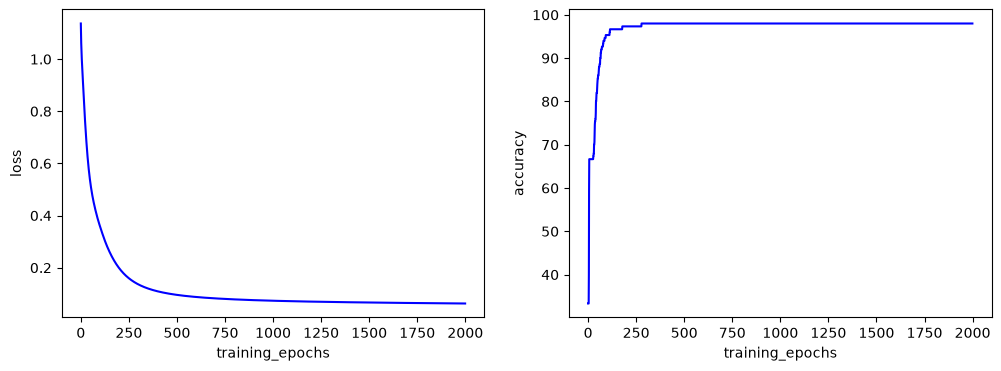

In [23]:
training_epochs = 2000
losses = np.zeros(training_epochs)
accuracies = np.zeros(training_epochs)

for epoch in range(training_epochs):
    # forward pass
    y_hat = model(data)

    # compute loss
    loss = loss_func(y_hat, labels)
    losses[epoch] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    matches = torch.argmax(y_hat, axis=1) == labels
    matches_num = matches.float()
    accuracy = 100 * torch.mean(matches_num)
    accuracies[epoch] = accuracy

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(losses, 'b-')
ax[0].set_xlabel('training_epochs')
ax[0].set_ylabel('loss')
ax[1].plot(accuracies, 'b-')
ax[1].set_xlabel('training_epochs')
ax[1].set_ylabel('accuracy')
plt.show()

In [24]:
# Experiment 3: how much does model breadth matter?
def createModel(n_hidden):
    model = nn.Sequential(
        nn.Linear(4, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 3)
    )
    loss_func = nn.CrossEntropyLoss()
    learning_rate = 0.02
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    return model, loss_func, optimizer

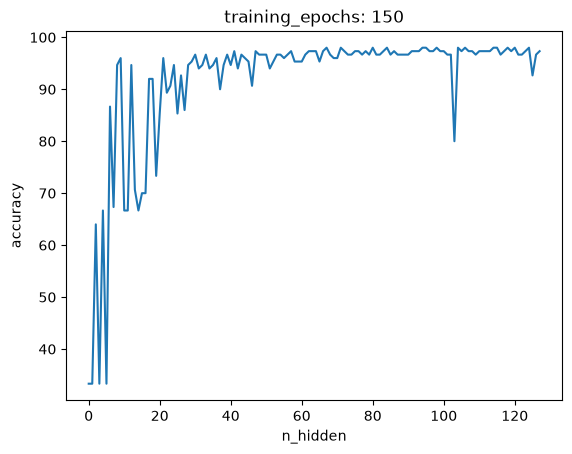

In [27]:
max_hidden = 128
accuracies = np.zeros(max_hidden)
training_epochs = 150

for n_hidden in range(max_hidden):
    model, loss_func, optimizer = createModel(n_hidden)

    for epoch in range(training_epochs):
        # forward pass
        y_hat = model(data)

        # compute loss
        loss = loss_func(y_hat, labels)

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictions = torch.softmax(model(data), axis=1)
    predictions_labels = predictions.argmax(axis=1)
    accuracy = 100 * torch.mean((predictions_labels == labels).float())
    accuracies[n_hidden] = accuracy

plt.plot(accuracies)
plt.ylabel('accuracy')
plt.xlabel('n_hidden')
plt.title('training_epochs: ' + str(training_epochs))
plt.show()